In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from qiskit.primitives import StatevectorSampler as Sampler

from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.algorithms import PegasosQSVC
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
#import os
#os.environ["OMP_NUM_THREADS"] = "8"
N_QUBITS = 8
df_data = pd.read_csv('features_geometry_70.csv')

X = df_data.drop(columns=['class', 'image_name'])
feature_cols = [
    "dist_thumb_index",
    "dist_index_middle",
    "dist_middle_ring",
    "dist_ring_pinky",
    "angle_index",
    "angle_middle",
    "angle_ring",
    "angle_pinky",
]

X = df_data[feature_cols]

y = df_data['class']

#pca = PCA(n_components=N_QUBITS)
#X_pca= pca.fit_transform(X)  

print(X.shape)



le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_cv_raw = df_data[feature_cols].to_numpy()
y_cv = le.fit_transform(df_data['class'].to_numpy())

print(f"Total: {X_cv_raw.shape}")

(45014, 8)
Total: (45014, 8)


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.optimizers import COBYLA, SPSA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from sklearn.model_selection import train_test_split

algorithm_globals.random_seed = 12345
estimator = Estimator()

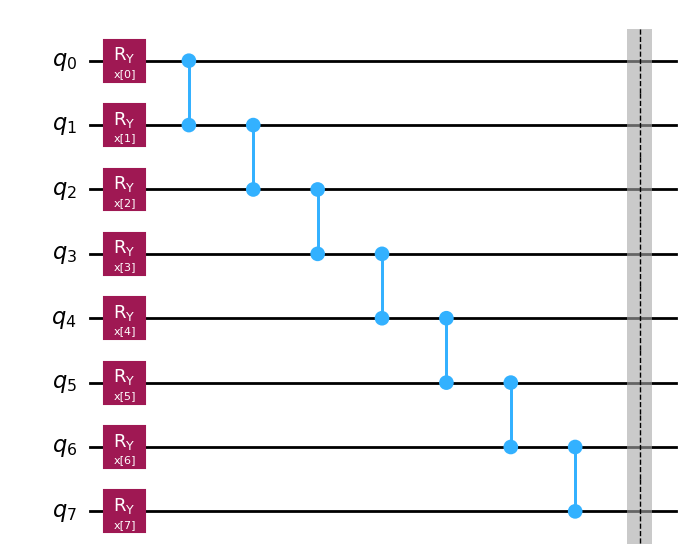

In [3]:
from math import ceil
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

num_features = 8
num_qubits = 8

data_vector = ParameterVector("x", num_features)

def build_data_reupload_only(num_qubits, num_features, data_vector):
    qc = QuantumCircuit(num_qubits)

    num_reuploads = ceil(num_features / num_qubits)
    feature_idx = 0

    for layer in range(num_reuploads):
        for q in range(num_qubits):
            if feature_idx < num_features:
                qc.ry(data_vector[feature_idx], q)
                feature_idx += 1

        for q in range(num_qubits - 1):
            qc.cz(q, q + 1)

        qc.barrier()

    return qc

reupload = build_data_reupload_only(
    num_qubits=num_qubits,
    num_features=num_features,
    data_vector=data_vector
)

reupload.draw("mpl")

Usando 8 qubits


/var/folders/2_/jlrh0qwn1n3fq71vkp57s1jc0000gn/T/ipykernel_4378/4160796936.py:25: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz =  RealAmplitudes(num_features, reps=2)


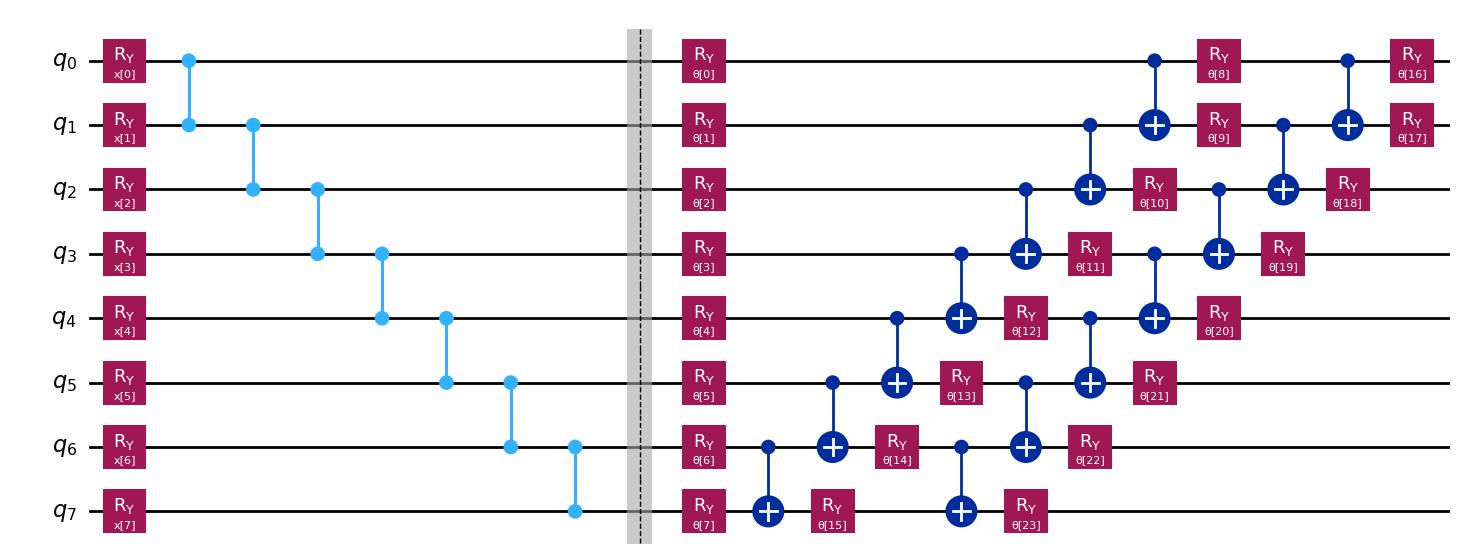

In [4]:
from qiskit.circuit.library import RealAmplitudes
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from sklearn.model_selection import train_test_split


num_features = 8       
print(f"Usando {num_features} qubits")



ansatz =  RealAmplitudes(num_features, reps=2) 


qc = QuantumCircuit(num_features)
qc.compose(reupload, inplace=True)
qc.compose(ansatz.decompose(), inplace=True)


qc.draw("mpl", fold=-1)

In [ ]:
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute

sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)


qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=reupload)

In [6]:
from qiskit_machine_learning.algorithms import PegasosQSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import time

def make_ovr_subset(X, y, target_class, neg_ratio=3, random_state=42):
    rng = np.random.default_rng(random_state + int(target_class))

    pos_idx = np.where(y == target_class)[0]
    neg_idx = np.where(y != target_class)[0]

    n_neg = min(len(neg_idx), len(pos_idx) * neg_ratio)
    neg_idx = rng.choice(neg_idx, size=n_neg, replace=False)

    idx = np.concatenate([pos_idx, neg_idx])
    rng.shuffle(idx)

    X_bin = X[idx]

    
    # PegasosQSVC mapeia o menor label para a classe positiva interna.
    # Por isso usamos 0 = classe alvo e 1 = resto.
    y_bin = np.where(y[idx] == target_class, 0, 1)

    return X_bin, y_bin


def train_ovr_pegasos(
    X_train,
    y_train,
    qkernel,
    classes=None,
    C=1000,
    num_steps=1000,
    neg_ratio=3,
    random_state=42
):
    if classes is None:
        classes = np.unique(y_train)

    binary_classifiers = {}

    print(f"Treinando One-vs-Rest com {len(classes)} classes")
    print(f"Amostras totais disponíveis: {len(X_train)}")

    total_t0 = time.time()

    for class_label in classes:
        X_bin, y_bin = make_ovr_subset(
            X_train,
            y_train,
            target_class=class_label,
            neg_ratio=neg_ratio,
            random_state=random_state
        )

        print(
            f"\nClasse {class_label} ({le.inverse_transform([class_label])[0]}) vs resto | "
            f"X_bin: {X_bin.shape}"
        )

        classifier = PegasosQSVC(
            quantum_kernel=qkernel,
            C=C,
            num_steps=num_steps,
            seed=random_state + int(class_label)
        )

        t0 = time.time()
        classifier.fit(X_bin, y_bin)
        elapsed = time.time() - t0

        binary_classifiers[class_label] = classifier

        print(f"Finalizado em {elapsed:.1f}s")

    total_elapsed = time.time() - total_t0
    print(f"\nTreino OVR finalizado em {total_elapsed:.1f}s")

    return binary_classifiers



In [7]:
from pathlib import Path
import pickle
import os
import time
import numpy as np

CHECKPOINT_DIR = Path("checkpoints") / "cv_checkpoints_pegasos_qsvc_v2"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def atomic_pickle_dump(obj, path):
    path = Path(path)
    tmp_path = path.with_suffix(path.suffix + ".tmp")

    with open(tmp_path, "wb") as f:
        pickle.dump(obj, f)

    os.replace(tmp_path, path)

def pickle_load(path):
    with open(path, "rb") as f:
        return pickle.load(f)

In [8]:

def predict_ovr_pegasos(
    X,
    binary_classifiers,
    classes,
    chunk_size=250,
    checkpoint_dir=None,
):
    y_pred = []
    all_scores = []

    classes = np.array(classes)

    if checkpoint_dir is not None:
        checkpoint_dir = Path(checkpoint_dir)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

    for start in range(0, len(X), chunk_size):
        end = min(start + chunk_size, len(X))

        chunk_ckpt = None
        if checkpoint_dir is not None:
            chunk_ckpt = checkpoint_dir / f"pred_{start}_{end}.pkl"

        if chunk_ckpt is not None and chunk_ckpt.exists():
            saved = pickle_load(chunk_ckpt)
            y_pred_chunk = np.array(saved["y_pred_chunk"])
            scores = np.array(saved["scores"])
            print(f"Chunk já predito {end}/{len(X)}. Carregado de checkpoint.")
        else:
            X_chunk = X[start:end]
            scores = np.zeros((len(X_chunk), len(classes)))

            for i, class_label in enumerate(classes):
                classifier = binary_classifiers[class_label]
                scores[:, i] = classifier.decision_function(X_chunk)

            best_idx = np.argmax(scores, axis=1)
            y_pred_chunk = classes[best_idx]

            if chunk_ckpt is not None:
                atomic_pickle_dump(
                    {
                        "start": start,
                        "end": end,
                        "y_pred_chunk": y_pred_chunk.tolist(),
                        "scores": scores,
                    },
                    chunk_ckpt,
                )

            print(f"Predito {end}/{len(X)}")

        y_pred.append(y_pred_chunk)
        all_scores.append(scores)

    return np.concatenate(y_pred), np.vstack(all_scores)

In [10]:
from sklearn.model_selection import StratifiedKFold

CV_N_SPLITS = 5
SEED = 42
CV_VAL_FRACTION_OF_TRAIN = 0.10

skf = StratifiedKFold(n_splits=CV_N_SPLITS, shuffle=True, random_state=SEED)

fold_metrics = []
all_y_true = []
all_y_pred = []

for fold_idx, (idx_train, idx_test) in enumerate(skf.split(X_cv_raw, y_cv), start=1):
    fold_dir = CHECKPOINT_DIR / f"fold_{fold_idx}"
    pred_dir = fold_dir / "predict_chunks"
    final_ckpt = fold_dir / "fold_final.pkl"

    fold_dir.mkdir(parents=True, exist_ok=True)

    if final_ckpt.exists():
        print(f"\n===== Fold {fold_idx}/{CV_N_SPLITS} já finalizado. Carregando =====")
        saved = pickle_load(final_ckpt)

        fold_metrics.append(saved["metrics"])
        all_y_true.extend(saved["y_true"])
        all_y_pred.extend(saved["y_pred"])
        continue

    print(f"\n===== Fold {fold_idx}/{CV_N_SPLITS} =====")
    t0 = time.time()

    idx_train_real, _, _, _ = train_test_split(
        idx_train,
        y_cv[idx_train],
        test_size=CV_VAL_FRACTION_OF_TRAIN,
        random_state=SEED + fold_idx,
        stratify=y_cv[idx_train],
    )

    scaler_fold = MinMaxScaler(feature_range=(0, np.pi))
    X_fold_train = scaler_fold.fit_transform(X_cv_raw[idx_train_real])
    X_fold_test = scaler_fold.transform(X_cv_raw[idx_test])

    y_fold_train = y_cv[idx_train_real]
    y_fold_test = y_cv[idx_test]

    classes = np.unique(y_fold_train)

    atomic_pickle_dump(
        {
            "fold": fold_idx,
            "idx_train_real": idx_train_real.tolist(),
            "idx_test": idx_test.tolist(),
            "classes": classes.tolist(),
            "scaler": scaler_fold,
            "y_test": y_fold_test.tolist(),
        },
        fold_dir / "fold_setup.pkl",
    )

    print(f"Treino={len(X_fold_train)} | Teste={len(X_fold_test)}")
    print(f"Checkpoint do setup salvo em: {fold_dir / 'fold_setup.pkl'}")

    binary_classifiers = train_ovr_pegasos(
        X_train=X_fold_train,
        y_train=y_fold_train,
        qkernel=qkernel,
        classes=classes,
        C=1000,
        num_steps=2000,
        neg_ratio=3,
        random_state=SEED,
    )

    y_pred_fold, scores_fold = predict_ovr_pegasos(
        X_fold_test,
        binary_classifiers,
        classes,
        chunk_size=500,
        checkpoint_dir=pred_dir,
    )

    acc = accuracy_score(y_fold_test, y_pred_fold)
    f1 = f1_score(y_fold_test, y_pred_fold, average="macro", zero_division=0)
    elapsed = time.time() - t0

    metrics = {
        "fold": fold_idx,
        "test_acc": acc,
        "test_f1": f1,
        "elapsed_min": elapsed / 60,
    }

    atomic_pickle_dump(
        {
            "metrics": metrics,
            "y_true": y_fold_test.tolist(),
            "y_pred": y_pred_fold.tolist(),
            "scores": scores_fold,
            "classes": classes.tolist(),
        },
        final_ckpt,
    )

    print(f"Fold {fold_idx} | acc={acc:.4f} | f1={f1:.4f} | {elapsed/60:.1f} min")
    print(f"Checkpoint final salvo em: {final_ckpt}")

    fold_metrics.append(metrics)
    all_y_true.extend(y_fold_test.tolist())
    all_y_pred.extend(y_pred_fold.tolist())


===== Fold 1/5 já finalizado. Carregando =====

===== Fold 2/5 já finalizado. Carregando =====

===== Fold 3/5 já finalizado. Carregando =====

===== Fold 4/5 já finalizado. Carregando =====

===== Fold 5/5 =====
Treino=32410 | Teste=9002
Checkpoint do setup salvo em: checkpoints/cv_checkpoints_pegasos_qsvc_v2/fold_5/fold_setup.pkl
Treinando One-vs-Rest com 21 classes
Amostras totais disponíveis: 32410

Classe 0 (A) vs resto | X_bin: (6088, 8)
Finalizado em 550.3s

Classe 1 (B) vs resto | X_bin: (6404, 8)
Finalizado em 596.1s

Classe 2 (C) vs resto | X_bin: (4788, 8)
Finalizado em 420.5s

Classe 3 (D) vs resto | X_bin: (6336, 8)
Finalizado em 613.1s

Classe 4 (E) vs resto | X_bin: (6460, 8)
Finalizado em 870.6s

Classe 5 (F) vs resto | X_bin: (5956, 8)
Finalizado em 444.8s

Classe 6 (G) vs resto | X_bin: (6336, 8)
Finalizado em 419.3s

Classe 7 (I) vs resto | X_bin: (6336, 8)
Finalizado em 305.3s

Classe 8 (L) vs resto | X_bin: (6336, 8)
Finalizado em 368.2s

Classe 9 (M) vs resto | X

In [11]:
metrics_df = pd.DataFrame(fold_metrics).sort_values("fold")

summary_result = {
    "fold_metrics": metrics_df.to_dict(orient="records"),
    "accuracy_mean": metrics_df["test_acc"].mean(),
    "accuracy_std": metrics_df["test_acc"].std(ddof=1),
    "macro_f1_mean": metrics_df["test_f1"].mean(),
    "macro_f1_std": metrics_df["test_f1"].std(ddof=1),
    "all_y_true": all_y_true,
    "all_y_pred": all_y_pred,
}

summary_path = CHECKPOINT_DIR / "cv_summary.pkl"
atomic_pickle_dump(summary_result, summary_path)

print(metrics_df.to_string(index=False))
print(f"\nAccuracy: {summary_result['accuracy_mean']:.4f} +/- {summary_result['accuracy_std']:.4f}")
print(f"Macro F1: {summary_result['macro_f1_mean']:.4f} +/- {summary_result['macro_f1_std']:.4f}")
print(f"\nResumo salvo em: {summary_path}")

 fold  test_acc  test_f1  elapsed_min
    1  0.904476 0.900783  1483.221474
    2  0.883261 0.874932  1506.034844
    3  0.912251 0.912901  1533.467878
    4  0.928135 0.927646  1504.359195
    5  0.912242 0.913782  1475.711804

Accuracy: 0.9081 +/- 0.0163
Macro F1: 0.9060 +/- 0.0198

Resumo salvo em: checkpoints/cv_checkpoints_pegasos_qsvc_v2/cv_summary.pkl


In [12]:
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=le.classes_,
    digits=4,
    zero_division=0,
))

              precision    recall  f1-score   support

           A     0.9837    0.8594    0.9174      2113
           B     0.8399    0.8705    0.8549      2224
           C     0.9481    0.9892    0.9682      1662
           D     0.8728    0.9641    0.9162      2200
           E     0.8422    0.8997    0.8700      2243
           F     0.8510    0.6820    0.7572      2069
           G     0.9663    0.9118    0.9383      2200
           I     0.9995    0.9905    0.9950      2200
           L     0.9957    0.9477    0.9711      2200
           M     0.9786    0.9046    0.9401      2169
           N     0.8852    0.9495    0.9162      2120
           O     0.9580    0.9893    0.9734      1868
           P     1.0000    0.8411    0.9137      2184
           Q     0.9977    0.9995    0.9986      2200
           R     0.8416    0.5607    0.6730      2199
           S     0.8851    0.9595    0.9208      2200
           T     0.7433    0.8859    0.8083      2164
           U     0.6686    

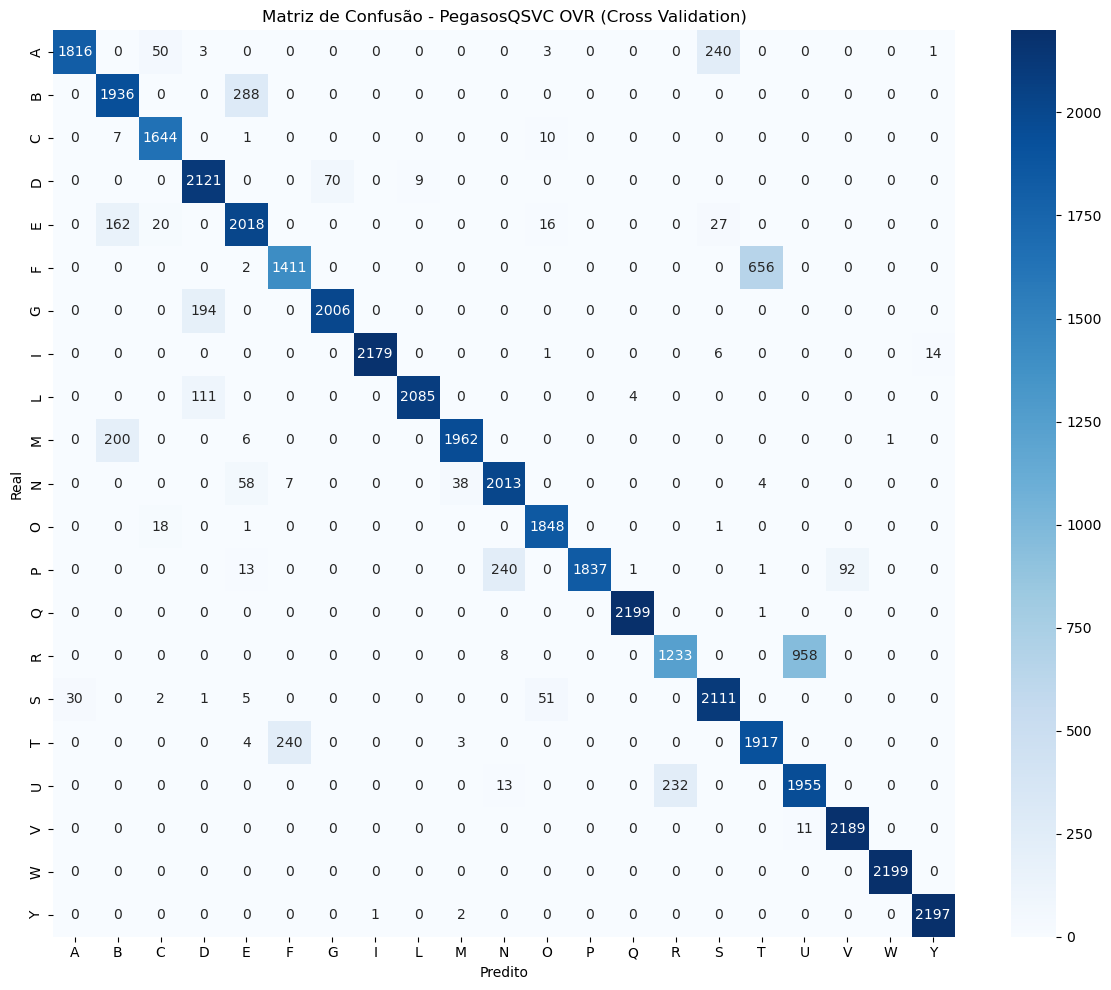

In [13]:
cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - PegasosQSVC OVR (Cross Validation)")
plt.tight_layout()
plt.show()
